### Content
- Plotting points with different colors intensity based on the frequency with which they have been recorded (both as starting/ending points of an e-scooters trip or in the middle of it) 
- Plotting trajectories of a random day with layer control to select trips
- Check most common stops of e-scooters trips (the most frequent considering all data for all days); barchart of frequency of all stops that appeared more than 50 times; map with stops that appeared more than 50 times, with markers of different colors based on their frequency
- use pyrosm to get data of location of public transport stops. Plot public transport stops and most frequent e-scooters trips stops, to check whether e-scooters concluded their ride near public transport stops, which means they may be used to commute to another form of transport (and not used just for fun – the use of e-scooters for very short paths suggest they may be used just for the fun of riding them, in which case they cannot be considered a real resource for sustainable mobility)

In [ ]:
try:
  import geopandas as gpd
except ModuleNotFoundError as e:
  !pip install geopandas==0.10.1
  import geopandas as gpd

if gpd.__version__ != "0.10.1":
  !pip install -U geopandas==0.10.1
  import geopandas as gpd

In [ ]:
try:
  import mapclassify
except ModuleNotFoundError as e:
  !pip install mapclassify
  import mapclassify

if mapclassify.__version__ != "2.4.3":
  !pip install -U mapclassify==2.4.3

In [ ]:
try:
  import contextily 
except ModuleNotFoundError as e:
  !pip install contextily==1.1.0
  import contextily

if contextily.__version__ != "1.1.0":
  !pip install -U contextily==1.1.0
  import contextily

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import contextily as ctx
import matplotlib.pyplot as plt 

In [ ]:
data = pd.read_parquet('trips_pointv3.parquet')

In [ ]:
data = gpd.GeoDataFrame(data, crs='EPSG:4326', geometry=gpd.points_from_xy(data.point_latitude, data.point_longitude))
data

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,geometry
0,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 22:51:07+00:00,46.069058,11.125847,0,None,POINT (46.06906 11.12585)
1,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 23:05:16+00:00,46.069185,11.125873,1,None,POINT (46.06918 11.12587)
2,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 22:52:32+00:00,46.069980,11.123846,0,None,POINT (46.06998 11.12385)
3,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 23:05:22+00:00,46.069166,11.125992,1,None,POINT (46.06917 11.12599)
4,BIT,Bit Mobility,00002677-0000-1000-9537-5b7d6a617b60,2021-12-31 23:32:46+00:00,46.064904,11.123108,0,None,POINT (46.06490 11.12311)
...,...,...,...,...,...,...,...,...,...
82751,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:18+00:00,46.060615,11.115260,53,None,POINT (46.06061 11.11526)
82752,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:27+00:00,46.060804,11.114903,54,None,POINT (46.06080 11.11490)
82753,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:38+00:00,46.060407,11.114829,55,None,POINT (46.06041 11.11483)
82754,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:47+00:00,46.060273,11.114973,56,None,POINT (46.06027 11.11497)


In [ ]:
len(pd.unique(data.point_trip_id))

6475

In [ ]:
data = data.astype({"point_latitude": float, "point_longitude": float}, errors='raise') 
type(data.point_latitude[0])

numpy.float64

In [ ]:
data.point_latitude = data.point_latitude.round(3)
data.point_longitude = data.point_longitude.round(3)

In [ ]:
data.groupby(['point_latitude','point_longitude']).size()

point_latitude  point_longitude
46.032          11.132             13
46.033          11.132             81
46.034          11.131              4
                11.132              3
46.035          11.131              5
                                   ..
46.113          11.090              1
                11.091              1
                11.108              1
46.114          11.090              6
                11.091              1
Length: 1063, dtype: int64

In [ ]:
df = pd.DataFrame(data.groupby(['point_latitude','point_longitude']).size()).reset_index()
df = df.rename(columns={0:'freq'})
df

,point_latitude,point_longitude,freq
0,46.032,11.132,13
1,46.033,11.132,81
2,46.034,11.131,4
3,46.034,11.132,3
4,46.035,11.131,5
...,...,...,...
1058,46.113,11.090,1
1059,46.113,11.091,1
1060,46.113,11.108,1
1061,46.114,11.090,6


In [ ]:
df = gpd.GeoDataFrame(df, crs='EPSG:4326', geometry=gpd.points_from_xy(df.point_longitude, df.point_latitude))

In [ ]:
!pip install xyzservices 
import xyzservices.providers as xyz

Plotting points by frequency

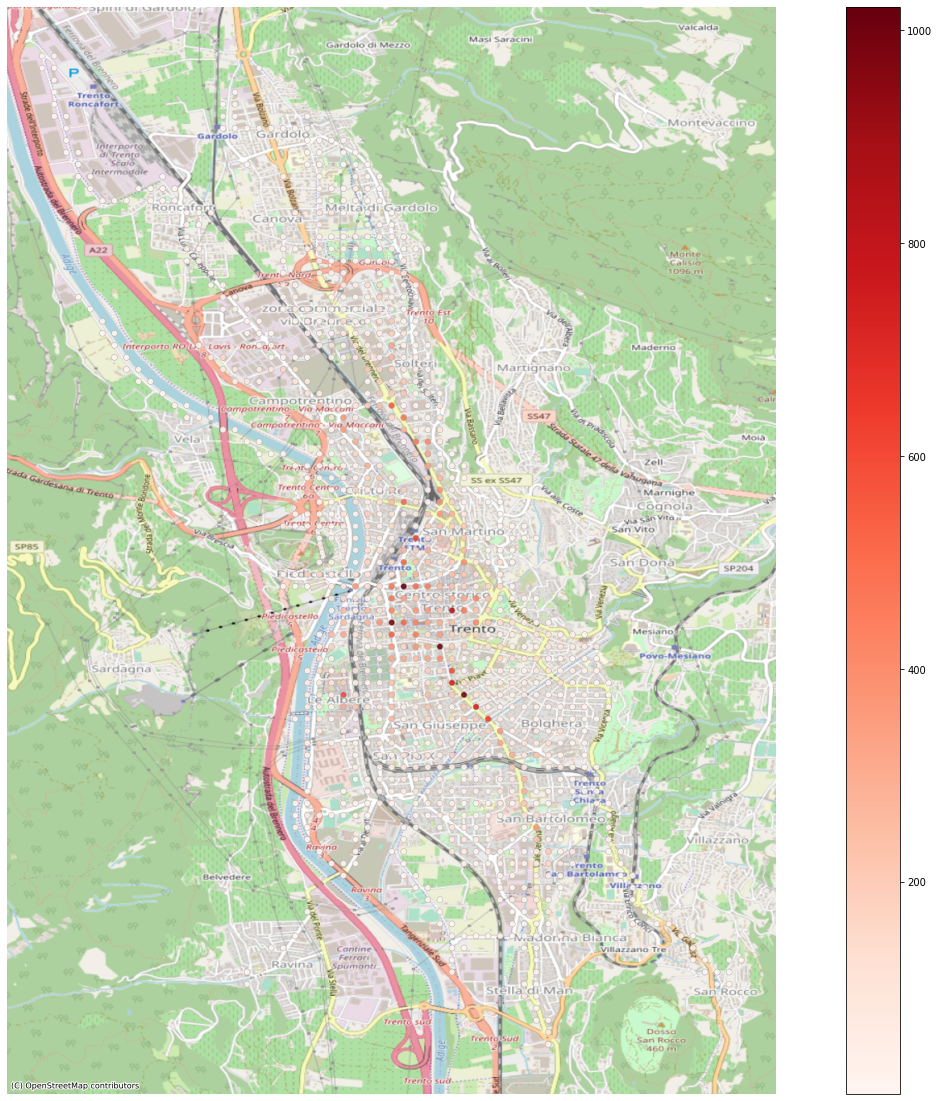

In [ ]:
fig, ax = plt.subplots(1, figsize=(25,20)) 

df.to_crs(epsg=4326).plot(column="freq",
                    alpha=.9, cmap="Reds", edgecolor = "darkgrey", 
                    legend=True, linewidth = 0.5,     
                    ax=ax)

ctx.add_basemap(ax, crs=df.to_crs(epsg=4326).crs.to_string(),  
               source=xyz.OpenStreetMap.Mapnik)

ax.set_axis_off()

### Plotting trajectories of a random day

In [ ]:
type(data.point_timestamp[0])
data_one_day = data[(data['point_timestamp'] >= '2022-02-20 00:00:00+00:00') & (data['point_timestamp'] < '2022-02-21 00:00:00+00:00')]
data_one_day = data_one_day.reset_index()
data_one_day


,index,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,geometry
0,78468,VENTO,Tier,f836e2a5-7155-4979-914e-7c4a42533801,2022-02-20 00:00:03+00:00,46.071,11.123,105,None,POINT (46.07132 11.12349)
1,78469,VENTO,Tier,f836e2a5-7155-4979-914e-7c4a42533801,2022-02-20 00:00:13+00:00,46.071,11.124,106,None,POINT (46.07131 11.12358)
2,78470,VENTO,Tier,f836e2a5-7155-4979-914e-7c4a42533801,2022-02-20 00:00:23+00:00,46.071,11.124,107,None,POINT (46.07110 11.12354)
3,78471,VENTO,Tier,f836e2a5-7155-4979-914e-7c4a42533801,2022-02-20 00:00:33+00:00,46.071,11.123,108,None,POINT (46.07086 11.12308)
4,78472,VENTO,Tier,f836e2a5-7155-4979-914e-7c4a42533801,2022-02-20 00:00:44+00:00,46.071,11.123,109,None,POINT (46.07070 11.12256)
...,...,...,...,...,...,...,...,...,...,...
2470,81067,VENTO,Tier,91e6756d-5fb6-4280-9270-19280cb614b1,2022-02-20 17:31:11+00:00,46.080,11.117,38,None,POINT (46.07981 11.11746)
2471,81068,VENTO,Tier,91e6756d-5fb6-4280-9270-19280cb614b1,2022-02-20 17:31:20+00:00,46.080,11.117,39,None,POINT (46.07977 11.11716)
2472,81069,VENTO,Tier,91e6756d-5fb6-4280-9270-19280cb614b1,2022-02-20 17:31:37+00:00,46.080,11.117,40,None,POINT (46.07977 11.11716)
2473,81588,BIT,Bit Mobility,000026ce-0000-1000-817e-5b7d6a617b60,2022-02-20 23:17:15+00:00,46.062,11.114,0,None,POINT (46.06213 11.11397)


In [ ]:
new_df = data_one_day.groupby('point_trip_id', as_index=False).aggregate({"point_latitude": lambda x: x.to_list(),
                                                                          "point_longitude": lambda x: x.to_list()})
new_df

,point_trip_id,point_latitude,point_longitude
0,00000078-0000-1000-9298-5b7d6a617b60,"[46.066, 46.061]","[11.12, 11.115]"
1,00000087-0000-1000-8b27-5b7d6a617b60,"[46.054, 46.074]","[11.136, 11.115]"
2,000000d6-0000-1000-92d6-5b7d6a617b60,"[46.061, 46.062]","[11.125, 11.129]"
3,00000178-0000-1000-80f8-5b7d6a617b60,"[46.07, 46.082]","[11.12, 11.123]"
4,000001d6-0000-1000-8136-5b7d6a617b60,"[46.069, 46.069]","[11.114, 11.114]"
...,...,...,...
182,ecc9991f-cbdf-44d1-9b8d-fd792de18eef,"[46.058, 46.058, 46.058, 46.058, 46.057, 46.05...","[11.118, 11.118, 11.118, 11.117, 11.117, 11.11..."
183,edf32e17-1415-40c5-8683-71b47b90acc7,"[46.082, 46.082, 46.082, 46.082, 46.082, 46.08...","[11.122, 11.122, 11.122, 11.122, 11.121, 11.12..."
184,f836e2a5-7155-4979-914e-7c4a42533801,"[46.071, 46.071, 46.071, 46.071, 46.071, 46.07...","[11.123, 11.124, 11.124, 11.123, 11.123, 11.12..."
185,fd2a0aa0-2899-460a-ad17-2d6d969eeb5a,"[46.049, 46.049, 46.049, 46.049, 46.05, 46.05,...","[11.131, 11.131, 11.131, 11.131, 11.131, 11.13..."


In [ ]:
new_df["coords"] = [ [[k,v] for k,v in zip(i,j)] for i,j in zip(new_df["point_latitude"], new_df["point_longitude"])]
new_df

,point_trip_id,point_latitude,point_longitude,coords
0,00000078-0000-1000-9298-5b7d6a617b60,"[46.066, 46.061]","[11.12, 11.115]","[[46.066, 11.12], [46.061, 11.115]]"
1,00000087-0000-1000-8b27-5b7d6a617b60,"[46.054, 46.074]","[11.136, 11.115]","[[46.054, 11.136], [46.074, 11.115]]"
2,000000d6-0000-1000-92d6-5b7d6a617b60,"[46.061, 46.062]","[11.125, 11.129]","[[46.061, 11.125], [46.062, 11.129]]"
3,00000178-0000-1000-80f8-5b7d6a617b60,"[46.07, 46.082]","[11.12, 11.123]","[[46.07, 11.12], [46.082, 11.123]]"
4,000001d6-0000-1000-8136-5b7d6a617b60,"[46.069, 46.069]","[11.114, 11.114]","[[46.069, 11.114], [46.069, 11.114]]"
...,...,...,...,...
182,ecc9991f-cbdf-44d1-9b8d-fd792de18eef,"[46.058, 46.058, 46.058, 46.058, 46.057, 46.05...","[11.118, 11.118, 11.118, 11.117, 11.117, 11.11...","[[46.058, 11.118], [46.058, 11.118], [46.058, ..."
183,edf32e17-1415-40c5-8683-71b47b90acc7,"[46.082, 46.082, 46.082, 46.082, 46.082, 46.08...","[11.122, 11.122, 11.122, 11.122, 11.121, 11.12...","[[46.082, 11.122], [46.082, 11.122], [46.082, ..."
184,f836e2a5-7155-4979-914e-7c4a42533801,"[46.071, 46.071, 46.071, 46.071, 46.071, 46.07...","[11.123, 11.124, 11.124, 11.123, 11.123, 11.12...","[[46.071, 11.123], [46.071, 11.124], [46.071, ..."
185,fd2a0aa0-2899-460a-ad17-2d6d969eeb5a,"[46.049, 46.049, 46.049, 46.049, 46.05, 46.05,...","[11.131, 11.131, 11.131, 11.131, 11.131, 11.13...","[[46.049, 11.131], [46.049, 11.131], [46.049, ..."


In [ ]:
new_df.sort_values(by="coords", key=lambda x: x.str.len())

,point_trip_id,point_latitude,point_longitude,coords
86,00001909-0000-1000-9f79-5b7d6a617b60,[46.067],[11.12],"[[46.067, 11.12]]"
0,00000078-0000-1000-9298-5b7d6a617b60,"[46.066, 46.061]","[11.12, 11.115]","[[46.066, 11.12], [46.061, 11.115]]"
95,00001a72-0000-1000-80d2-5b7d6a617b60,"[46.06, 46.071]","[11.115, 11.12]","[[46.06, 11.115], [46.071, 11.12]]"
96,00001a7e-0000-1000-924e-5b7d6a617b60,"[46.069, 46.069]","[11.114, 11.126]","[[46.069, 11.114], [46.069, 11.126]]"
97,00001a97-0000-1000-85e7-5b7d6a617b60,"[46.061, 46.067]","[11.115, 11.12]","[[46.061, 11.115], [46.067, 11.12]]"
...,...,...,...,...
172,b7b708a8-7440-4a66-9128-a12bec7cad34,"[46.07, 46.069, 46.069, 46.068, 46.068, 46.067...","[11.127, 11.127, 11.127, 11.127, 11.126, 11.12...","[[46.07, 11.127], [46.069, 11.127], [46.069, 1..."
167,a8f5ac67-bdec-4064-ae40-aba9ef5e32c8,"[46.066, 46.066, 46.066, 46.066, 46.066, 46.06...","[11.125, 11.125, 11.125, 11.125, 11.126, 11.12...","[[46.066, 11.125], [46.066, 11.125], [46.066, ..."
176,c0907311-7b6f-4ee7-af24-2ecb1183145e,"[46.077, 46.077, 46.077, 46.077, 46.077, 46.07...","[11.119, 11.119, 11.119, 11.118, 11.118, 11.11...","[[46.077, 11.119], [46.077, 11.119], [46.077, ..."
179,dd9f435b-7d2e-4006-a41d-c7b20a46df41,"[46.058, 46.058, 46.058, 46.058, 46.058, 46.05...","[11.118, 11.118, 11.118, 11.118, 11.118, 11.11...","[[46.058, 11.118], [46.058, 11.118], [46.058, ..."


In [ ]:
from branca.element import Figure
import random

fig = Figure(height=550,width=750)
m = folium.Map(location=[46.066, 11.133], tiles='cartodbpositron', zoom_start=14)
fig.add_child(m)

n=1
  
for i in range(len(new_df)):
  points = []
  points.append(new_df.coords[i])
  feat = folium.FeatureGroup("Vehicle"+ str(n), show=False)
  
  popup = 'trip n. '+str(n)
  color = ["#"+''.join([random.choice('ABCDEF0123456789') for i in range(6)])]
  n+=1

  folium.vector_layers.PolyLine(points, popup=popup, tooltip=popup, color=color).add_to(feat)
  feat.add_to(m)


m.add_child(folium.LayerControl())

m



In [ ]:
import folium
from  folium import plugins
m=folium.Map(width=750, height=550, location=[46.066, 11.133], zoom_start=14, min_zoom=8, max_zoom = 20)


n=1
  
for i in range(len(new_df)):
  points = []
  points.append(new_df.coords[i])
  popup = 'trip n. '+str(n)
  color = ["#"+''.join([random.choice('ABCDEF0123456789') for i in range(6)])]

  feat = folium.FeatureGroup("Vehicle"+ str(n), show=False)
  plugins.AntPath(points, popup=popup, tooltip=popup, **{'color':color}).add_to(feat)
  
  n+=1

  feat.add_to(m)


m.add_child(folium.LayerControl())




m

### Checking most common stops of e-scooters rides (end of trajectories)

In [ ]:
# ending pt of trajectories
data
data["coords"] = [ (i,j) for i,j in zip(data["point_latitude"], data["point_longitude"])]
data

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,geometry,coords
0,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 22:51:07+00:00,46.069,11.126,0,None,POINT (46.06906 11.12585),"(46.069, 11.126)"
1,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 23:05:16+00:00,46.069,11.126,1,None,POINT (46.06918 11.12587),"(46.069, 11.126)"
2,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 22:52:32+00:00,46.070,11.124,0,None,POINT (46.06998 11.12385),"(46.07, 11.124)"
3,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 23:05:22+00:00,46.069,11.126,1,None,POINT (46.06917 11.12599),"(46.069, 11.126)"
4,BIT,Bit Mobility,00002677-0000-1000-9537-5b7d6a617b60,2021-12-31 23:32:46+00:00,46.065,11.123,0,None,POINT (46.06490 11.12311),"(46.065, 11.123)"
...,...,...,...,...,...,...,...,...,...,...
82751,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:18+00:00,46.061,11.115,53,None,POINT (46.06061 11.11526),"(46.061, 11.115)"
82752,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:27+00:00,46.061,11.115,54,None,POINT (46.06080 11.11490),"(46.061, 11.115)"
82753,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:38+00:00,46.060,11.115,55,None,POINT (46.06041 11.11483),"(46.06, 11.115)"
82754,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:47+00:00,46.060,11.115,56,None,POINT (46.06027 11.11497),"(46.06, 11.115)"


In [ ]:
ending=[]

for id in range(len(data.point_trip_id)):
  if id==0:
    continue
  elif id==len(data.point_trip_id)-1:
    ending.append(data.coords[id])
  else:
    if data.point_trip_id[id] != data.point_trip_id[id+1]:
      ending.append(data.coords[id])
    else:
      continue

In [ ]:
len(ending)

11679

In [ ]:
from collections import Counter

print(Counter(ending))

Counter({(46.068, 11.124): 247, (46.07, 11.12): 234, (46.061, 11.115): 202, (46.069, 11.126): 195, (46.065, 11.123): 173, (46.072, 11.12): 141, (46.061, 11.125): 136, (46.074, 11.121): 135, (46.067, 11.12): 120, (46.078, 11.12): 115, (46.056, 11.131): 115, (46.082, 11.122): 110, (46.067, 11.119): 109, (46.06, 11.115): 106, (46.077, 11.12): 104, (46.069, 11.125): 99, (46.069, 11.119): 90, (46.067, 11.126): 90, (46.061, 11.119): 85, (46.063, 11.124): 84, (46.057, 11.113): 84, (46.07, 11.122): 82, (46.05, 11.131): 78, (46.072, 11.119): 77, (46.047, 11.132): 77, (46.066, 11.117): 73, (46.07, 11.121): 73, (46.062, 11.124): 69, (46.066, 11.115): 69, (46.066, 11.121): 68, (46.069, 11.127): 66, (46.06, 11.116): 64, (46.076, 11.117): 64, (46.068, 11.125): 63, (46.067, 11.123): 62, (46.084, 11.12): 59, (46.068, 11.126): 58, (46.07, 11.119): 57, (46.067, 11.118): 56, (46.066, 11.119): 54, (46.069, 11.114): 52, (46.06, 11.126): 52, (46.047, 11.133): 51, (46.072, 11.125): 51, (46.07, 11.128): 49, (

In [ ]:
d=Counter(ending)
coord=d.keys()
freq=d.values()


df = pd.DataFrame.from_dict({'coord':coord, 'freq':freq})

df.drop(df[df.freq < 50].index, inplace=True)

df = df.reset_index()
df = df.drop(columns=['index'])
df = df.sort_values(by=['freq'], ascending=False)
df.head()

,coord,freq
1,"(46.068, 11.124)",247
7,"(46.07, 11.12)",234
2,"(46.061, 11.115)",202
0,"(46.069, 11.126)",195
27,"(46.065, 11.123)",173


In [ ]:
from geopy.geocoders import Nominatim

# initialize Nominatim API 
geolocator = Nominatim(user_agent="geoapi")

place = {}
for row in range(len(df)):
  place[row] = geolocator.reverse(str(df.coord[row]))

In [ ]:
df['location']=''
for row in range(len(df)):
  p = str(place[row]).split('(')
  p = p[0].split(',')
  df.at[row,'location']=p[0]+p[1]+p[2]+p[4]

df

,coord,freq,location
1,"(46.068, 11.124)",247,21 Via Mantova Bolghera Trento
7,"(46.07, 11.12)",234,20 Via Torre Vanga Bolghera Vela
2,"(46.061, 11.115)",202,33 Viale della Costituzione Clarina Sardagna
0,"(46.069, 11.126)",195,Liceo Musicale Coreutico Bonporti 16 Via Santa...
27,"(46.065, 11.123)",173,Ufficio Anagrafe Comune di Trento Via al Torri...
17,"(46.072, 11.12)",141,Giosuè Carducci Piazza Dante Centro storico Tr...
9,"(46.061, 11.125)",136,"Liceo ""Antonio Rosmini"" - Trento 2 Via Bartolo..."
10,"(46.074, 11.121)",135,P2 - Garage Centro Europa Via Giovanni Seganti...
13,"(46.067, 11.12)",120,Facoltà di Giurisprudenza 53 Via Giuseppe Verd...
16,"(46.078, 11.12)",115,Il Biscione 15 Corso degli Alpini Martignano


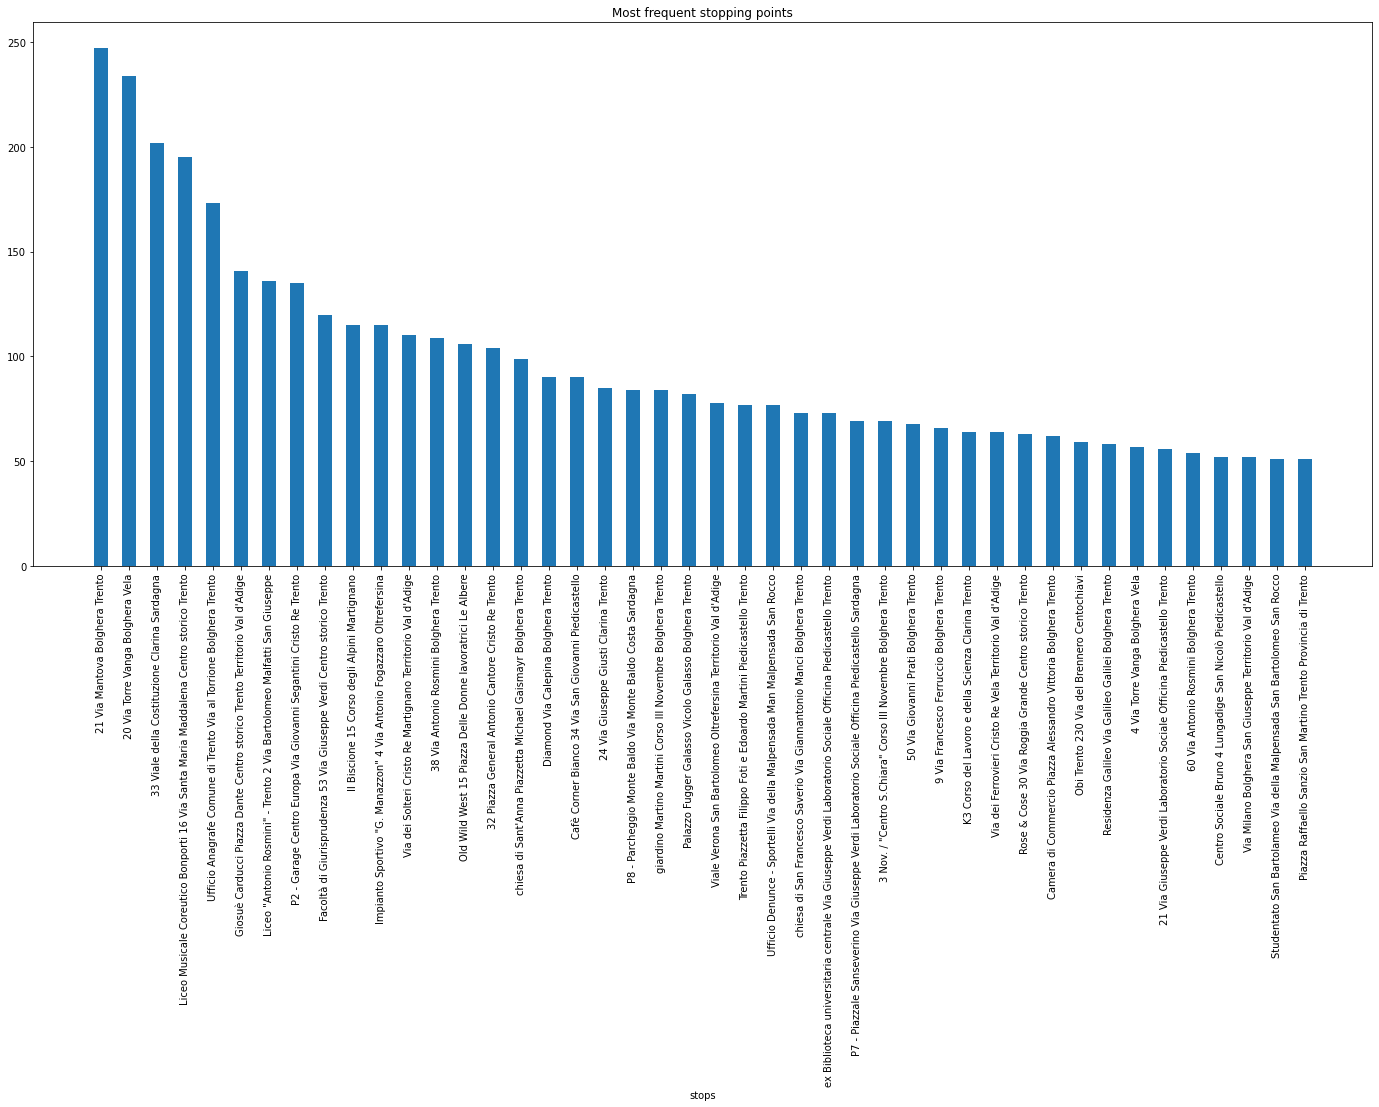

In [ ]:
# plt.bar(np.arange(len(df.freq)), df.freq)
# plt.show()

fig = plt.figure(figsize=(24,10))

xs = np.arange(len(df.coord))

xs_labels = df.location.to_list()

ys = df.freq.to_list()

plt.bar(xs, ys, 0.5, align='center')

plt.title("Most frequent stopping points")
plt.xticks(xs, xs_labels, rotation=90)

plt.xlabel('stops')


plt.show()

In [ ]:
def color_func(freq):
  if freq > 150:
    return 'green'
  elif freq<150 and freq>60:
    return 'orange'
  elif freq<60:
    return 'red'


map = folium.Map(width=750, height=550, location=[46.066, 11.133], zoom_start=14, max_zoom=20)
for point in range(0, len(df.coord)):
  iframe = folium.IFrame(df['location'][point], width=500, height=50) 
  popup = folium.Popup(iframe)
  folium.Marker(df.coord[point], popup=popup, icon=folium.Icon(color=color_func(df.freq[point]), icon_color='white')).add_to(map)
map

### Try to understand if the e-scooters are used to commute to another means of transport by checking if the ending points of the trip are close to public transport stops

In [ ]:
try:
  import pyrosm
except ModuleNotFoundError as e:
  !pip install pyrosm==0.6.1
  import pyrosm

/usr/local/lib/python3.7/dist-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.10.2-CAPI-1.16.0) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [ ]:
import os
import sys 
from google.colab import drive 
import glob

path = "/content/drive" 
drive.mount(path, force_remount=True)  
data_path = "drive/MyDrive/Colab Notebooks" 

myfiles = glob.glob(os.path.join(data_path, '*')) 
print(myfiles)

Mounted at /content/drive
['drive/MyDrive/Colab Notebooks/ML_ImageSearchEngine', 'drive/MyDrive/Colab Notebooks/GeospatialAnalysis', 'drive/MyDrive/Colab Notebooks/Copia di Learning Bayesian Networks.ipynb', 'drive/MyDrive/Colab Notebooks/tensorflow-lab.ipynb', 'drive/MyDrive/Colab Notebooks/BIG_DATA_PRJ_NLP_part', 'drive/MyDrive/Colab Notebooks/Geosp_prj', 'drive/MyDrive/Colab Notebooks/NLP_SmallPrj', 'drive/MyDrive/Colab Notebooks/sklearn-lab.ipynb', 'drive/MyDrive/Colab Notebooks/traiettorie.ipynb', 'drive/MyDrive/Colab Notebooks/trento.pbf']


In [ ]:
import os
trento_download_pbf_url = "https://osmit-estratti.wmcloud.org/dati/poly/comuni/pbf/022205_Trento_poly.osm.pbf"
# download the data
import requests
#request the file
r = requests.get(trento_download_pbf_url, allow_redirects=True)
#save the file
open(data_path+'/trento.pbf', 'wb').write(r.content)

osm = pyrosm.OSM("trento.pbf")
osm.conf.tags.available


['aerialway',
 'aeroway',
 'amenity',
 'boundary',
 'building',
 'craft',
 'emergency',
 'geological',
 'highway',
 'historic',
 'landuse',
 'leisure',
 'natural',
 'office',
 'power',
 'public_transport',
 'railway',
 'route',
 'place',
 'shop',
 'tourism',
 'waterway']

In [ ]:
custom_filter = {'public_transport': True}
pois = osm.get_pois(custom_filter=custom_filter)
pois

/usr/local/lib/python3.7/dist-packages/pyrosm/pyrosm.py:583: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  self.bounding_box,


,id,lon,version,timestamp,tags,lat,changeset,addr:housenumber,addr:street,name,operator,ref,public_transport,geometry,osm_type
0,248009842,11.139458,9,1645443129,"{""highway"":""bus_stop"",""shelter"":""no""}",46.067120,0.0,None,None,"Mesiano / ""Fac. Ingegneria""",None,None,platform,POINT (11.13946 46.06712),node
1,248049459,11.136446,22,1645443129,"{""bench"":""no"",""bin"":""yes"",""highway"":""bus_stop""...",46.069290,0.0,None,None,"Valsugana / ""Corallo""",None,None,platform,POINT (11.13645 46.06929),node
2,248049727,11.139605,9,1645443129,"{""highway"":""bus_stop"",""shelter"":""yes"",""tactile...",46.067230,0.0,None,None,"Mesiano / ""Fac. Ingegneria""",None,None,platform,POINT (11.13960 46.06723),node
3,248050135,11.138317,10,1573574250,"{""bus"":""yes"",""highway"":""bus_stop""}",46.071602,0.0,None,None,San Donà,None,None,platform,POINT (11.13832 46.07160),node
4,248050308,11.140239,10,1631289227,"{""bench"":""no"",""bin"":""yes"",""bus"":""yes"",""highway...",46.069496,0.0,None,None,"""Ponte Lodovico""",None,None,platform,POINT (11.14024 46.06950),node
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,768139911,NaN,2,1581020851,"{""bus"":""yes"",""highway"":""platform""}",NaN,NaN,NaN,NaN,None,NaN,5,platform,"LINESTRING (11.11874 46.07040, 11.11820 46.07027)",way
747,768139912,NaN,2,1581020851,"{""bus"":""yes"",""highway"":""platform""}",NaN,NaN,NaN,NaN,None,NaN,4,platform,"LINESTRING (11.11884 46.07053, 11.11874 46.07040)",way
748,820475800,NaN,1,1593367565,"{""bus"":""yes"",""highway"":""footway"",""surface"":""as...",NaN,NaN,NaN,NaN,None,NaN,None,platform,"MULTILINESTRING ((11.15192 46.06397, 11.15192 ...",way
749,988537881,NaN,1,1633081163,"{""bus"":""yes"",""highway"":""footway"",""surface"":""as...",NaN,NaN,NaN,NaN,None,NaN,None,platform,"MULTILINESTRING ((11.11663 46.08919, 11.11651 ...",way


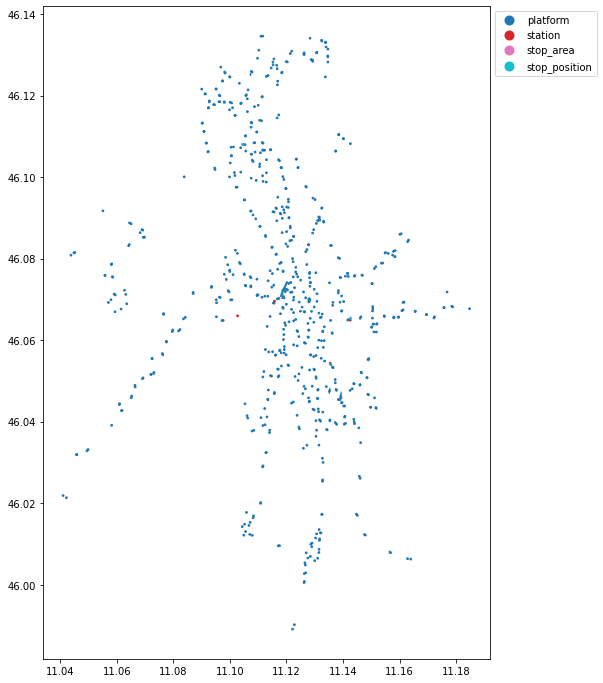

In [ ]:
pois["poi_type"] = pois["public_transport"]
pois["poi_type"] = pois["poi_type"].fillna(pois["public_transport"])

# Plot
ax = pois.plot(column='poi_type', markersize=3, figsize=(12,12), legend=True, legend_kwds=dict(loc='upper left', ncol=1, bbox_to_anchor=(1, 1)))

In [ ]:
pois = pois.dropna(subset=['lon','lat'])
pois.head()

,id,lon,version,timestamp,tags,lat,changeset,addr:housenumber,addr:street,name,operator,ref,public_transport,geometry,osm_type,poi_type
0,248009842,11.139458,9,1645443129,"{""highway"":""bus_stop"",""shelter"":""no""}",46.067120,0.0,None,None,"Mesiano / ""Fac. Ingegneria""",None,None,platform,POINT (11.13946 46.06712),node,platform
1,248049459,11.136446,22,1645443129,"{""bench"":""no"",""bin"":""yes"",""highway"":""bus_stop""...",46.069290,0.0,None,None,"Valsugana / ""Corallo""",None,None,platform,POINT (11.13645 46.06929),node,platform
2,248049727,11.139605,9,1645443129,"{""highway"":""bus_stop"",""shelter"":""yes"",""tactile...",46.067230,0.0,None,None,"Mesiano / ""Fac. Ingegneria""",None,None,platform,POINT (11.13960 46.06723),node,platform
3,248050135,11.138317,10,1573574250,"{""bus"":""yes"",""highway"":""bus_stop""}",46.071602,0.0,None,None,San Donà,None,None,platform,POINT (11.13832 46.07160),node,platform
4,248050308,11.140239,10,1631289227,"{""bench"":""no"",""bin"":""yes"",""bus"":""yes"",""highway...",46.069496,0.0,None,None,"""Ponte Lodovico""",None,None,platform,POINT (11.14024 46.06950),node,platform


In [ ]:
transport=[]
for row in range(len(pois)):
  transport.append((pois.lat[row], pois.lon[row]))

In [ ]:
import folium
from folium.plugins import BeautifyIcon

map = folium.Map(width=750, height=550, location=[46.066, 11.133], zoom_start=14)

# public transports
for pt in transport:
  icon_circle = BeautifyIcon(icon_shape='circle-dot', border_color='green', border_width=5)
  folium.Marker(pt, tooltip='public transport stop', icon=icon_circle).add_to(map)

# ending points trips
for point in range(0, len(df.coord)):
  iframe = folium.IFrame(df['location'][point] + '<br>Frequency: ' + str(df['freq'][point]), width=500, height=50) 
  popup = folium.Popup(iframe)
  folium.Marker(df.coord[point], popup=popup, icon=folium.Icon(color=color_func(df.freq[point]), icon_color='white')).add_to(map)

map